In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [6]:
df.describe()

,Дата,Склад,Количество
count,301355,301355.000000,301355.000000
mean,2018-05-03 18:58:36.652453632,2.900652,2.951559
min,2018-01-04 00:00:00,1.000000,0.000000
25%,2018-03-03 00:00:00,2.000000,1.000000
50%,2018-05-04 00:00:00,3.000000,2.000000
75%,2018-07-04 00:00:00,4.000000,4.000000
max,2018-08-31 00:00:00,5.000000,200.000000
std,NaN,1.352221,2.998154


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df['Дата'].dtype

dtype('<M8[ns]')

Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [8]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

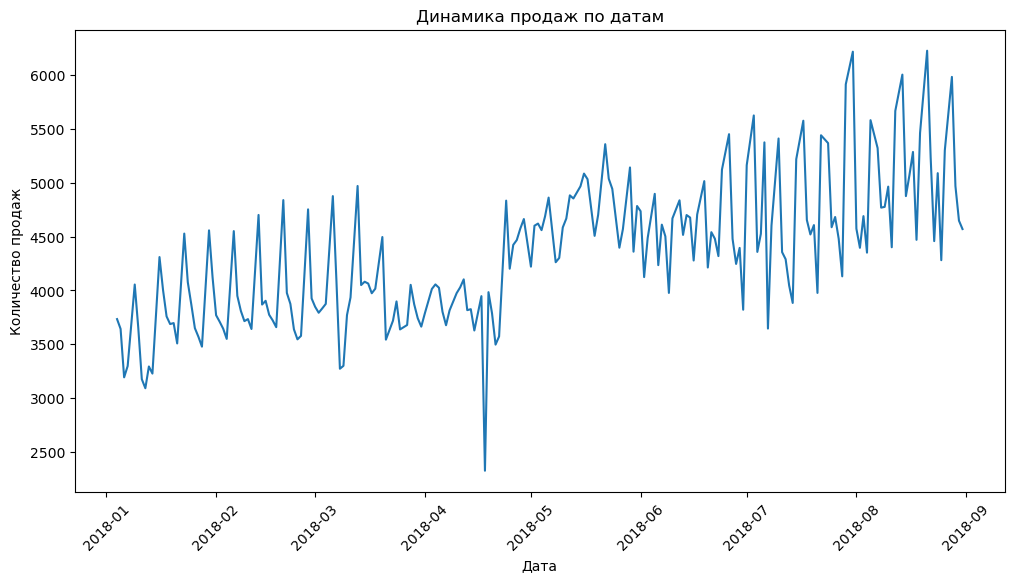

In [12]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Линейный график, отображающий динамику продаж за период с января по конец августа 2018 года. На протяжении всего рассматриваемого периода 
наблюдается отчетливый рост объемов продаж. Если в январе средний уровень колебался в районе 3500–4000 продаж, то к августу он поднялся 
до 5000–5500 продаж.
Ярко выраженная цикличность (сезонность): График имеет пилообразную структуру с постоянными резкими колебаниями вверх и вниз. Это указывает
на регулярную циклическую активность (вероятнее всего, недельную сезонность: например, спад в будни и пик в выходные, либо наоборот).
Январь – Март 2018: Стабильные колебания в коридоре от 3000 до 4700 продаж с плавным ростом. В марте виден локальный пик, приближающийся
к 5000 продаж.
Апрель 2018: Период относительного затишья. Амплитуда колебаний сужается, показатели держатся в районе 3500–4000.
Середина апреля: зафиксировано резкое аномальное падение (выброс вниз) — продажи упали почти до 2300, что является абсолютным минимумом на
всем графике. 
Май – Июнь 2018: После провала в конце апреля происходит резкий скачок вверх (более 4500), после чего график стабилизируется на новом, 
более высоком уровне (в среднем около 4500–5000 продаж). При этом в июне размах колебаний (амплитуда) временно уменьшается.
Июль – Август 2018: Период максимальной активности. Амплитуда колебаний снова сильно увеличивается. В августе график достигает своего 
абсолютного максимума — пиковые значения превышают 6000 продаж.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
grouped_df.loc[grouped_df['Количество'].idxmin()]

Дата          2018-04-18 00:00:00
Количество                   2326
Name: 88, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [17]:
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.day_name()
filtered_df = df[(df['Склад'] == 3) & (df['Месяц'].isin([6, 7, 8])) & (df['День_недели'] == 'Wednesday')]
top_products = filtered_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_products.loc[top_products['Количество'].idxmax()]
top_product

Номенклатура    product_1
Количество           2267
Name: 1, dtype: object

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [48]:
weather = pd.read_csv('arhiv_pogody.csv.gz',compression='gzip',sep=';',skiprows=6,encoding='utf-8', engine='python', index_col=False)
weather.head()
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [49]:
weather = weather[['Местное время в Астане', 'T']]

In [50]:
weather = weather.iloc[:, :2]
weather.columns = ['Дата', 'T']
weather.head()

,Дата,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [54]:
weather['Дата'] = pd.to_datetime(weather['Дата'],format='%d.%m.%Y %H:%M')
weather_daily = (weather.groupby(weather['Дата'].dt.date)['T'].mean().reset_index())
weather_daily.columns = ['Дата', 'T']
weather_daily['T'] = weather_daily['T'].round(1)
weather_daily.head()

,Дата,T
0,2018-01-01,-9.5
1,2018-01-02,-9.5
2,2018-01-03,-11.5
3,2018-01-04,-14.1
4,2018-01-05,-16.9


In [62]:
weather_daily.info()
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Дата    243 non-null    datetime64[ns]
 1   T       243 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Дата        205 non-null    datetime64[ns]
 1   Количество  205 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.3 KB


In [63]:
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата'])
weather_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Дата    243 non-null    datetime64[ns]
 1   T       243 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 KB


In [64]:
merged_df = grouped_df.merge(weather_daily, on='Дата', how='inner')
merged_df.head()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Дата        205 non-null    datetime64[ns]
 1   Количество  205 non-null    int64         
 2   T           205 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 4.9 KB


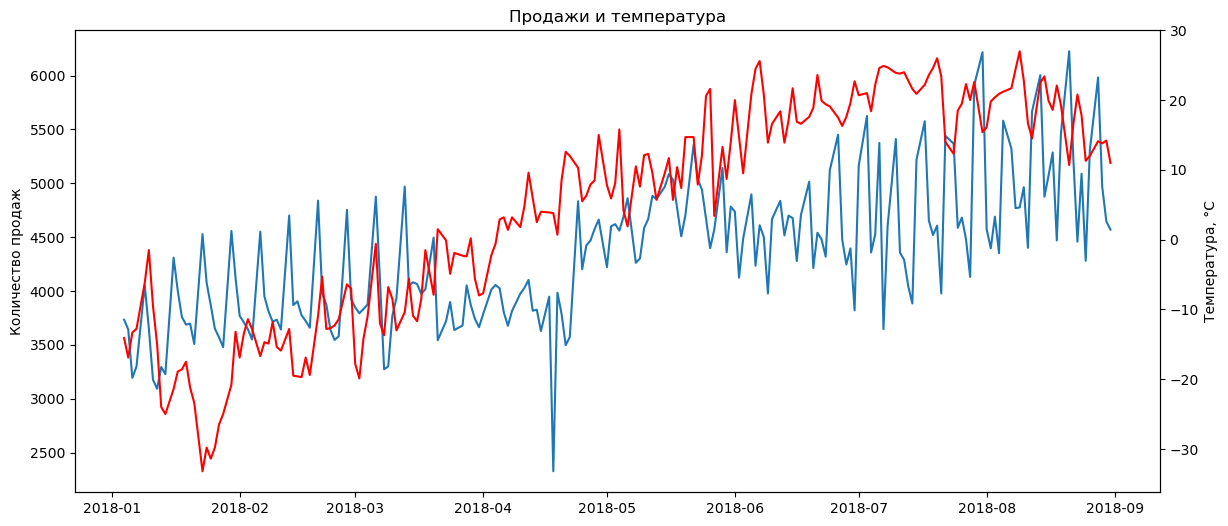

In [65]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж')
ax1.set_ylabel('Количество продаж')
ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='red', label='Температура')
ax2.set_ylabel('Температура, °C')
plt.title('Продажи и температура')
plt.xticks(rotation=45)
plt.show()

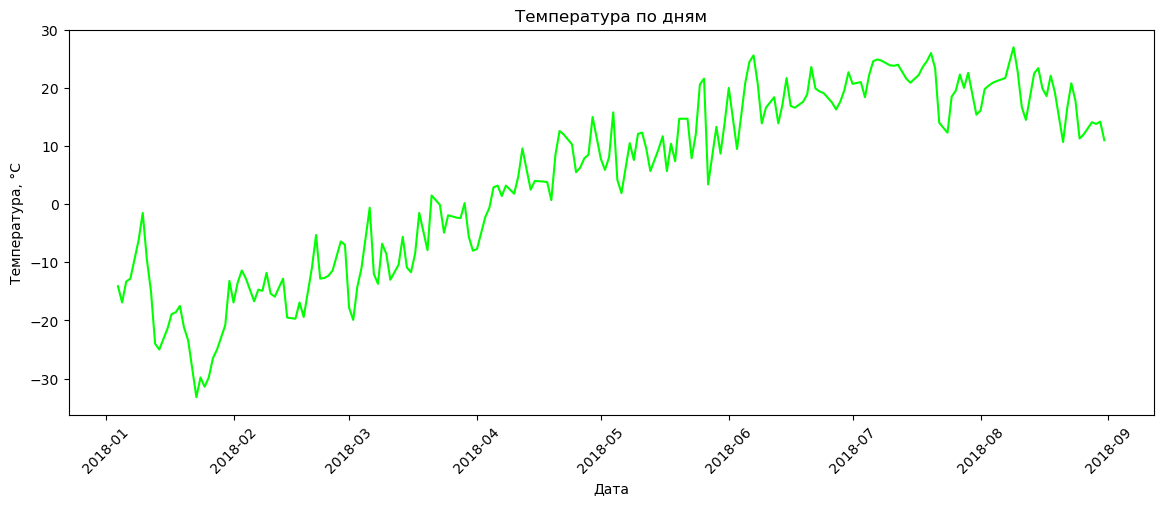

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(merged_df['Дата'], merged_df['T'], color='lime')
plt.title('Температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.xticks(rotation=45)
plt.show()